# Cubic Hermite Interpolation Functions

For a fourth-order differential equation such as the Euler--Bernoulli beam equation, the finite-element approximation must provide continuity of both the displacement and the slope.

For a two-node beam element,

$$
w_h^e(\bar{x})
=
\Delta_1^e\phi_1^e(\bar{x})
+
\Delta_2^e\phi_2^e(\bar{x})
+
\Delta_3^e\phi_3^e(\bar{x})
+
\Delta_4^e\phi_4^e(\bar{x})
=
\sum_{j=1}^{4}\Delta_j^e\phi_j^e(\bar{x})$$

with

$$
0\leq \bar{x}\leq h_e.$$


## Hermite interpolation functions

The four cubic Hermite interpolation functions are

$$
\phi_1^e(\bar{x})
=
1-3\left(\frac{\bar{x}}{h_e}\right)^2
+2\left(\frac{\bar{x}}{h_e}\right)^3,
$$

$$
\phi_2^e(\bar{x})
=
-\bar{x}\left(1-\frac{\bar{x}}{h_e}\right)^2,
$$

$$
\phi_3^e(\bar{x})
=
3\left(\frac{\bar{x}}{h_e}\right)^2
-2\left(\frac{\bar{x}}{h_e}\right)^3,
$$

$$
\phi_4^e(\bar{x})
=
-\bar{x}\left[
\left(\frac{\bar{x}}{h_e}\right)^2
-\frac{\bar{x}}{h_e}
\right].
$$


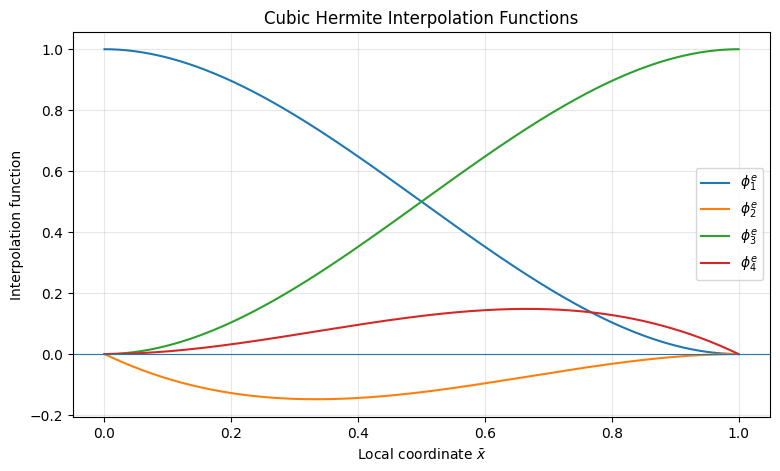

In [1]:
import numpy as np
import matplotlib.pyplot as plt

he = 1.0
xbar = np.linspace(0, he, 400)
xi = xbar/he

phi1 = 1 - 3*xi**2 + 2*xi**3
phi2 = -xbar*(1 - xi)**2
phi3 = 3*xi**2 - 2*xi**3
phi4 = -xbar*(xi**2 - xi)

plt.figure(figsize=(9,5))
plt.plot(xbar, phi1, label=r'$\phi_1^e$')
plt.plot(xbar, phi2, label=r'$\phi_2^e$')
plt.plot(xbar, phi3, label=r'$\phi_3^e$')
plt.plot(xbar, phi4, label=r'$\phi_4^e$')
plt.axhline(0, linewidth=0.8)
plt.xlabel(r'Local coordinate $\bar{x}$')
plt.ylabel('Interpolation function')
plt.title('Cubic Hermite Interpolation Functions')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Why not use cubic Lagrange interpolation?

A cubic Lagrange interpolation is also a third-order polynomial, so at first it may seem that it should work equally well.

The issue is not the polynomial order.

A standard Lagrange element uses only values of the primary variable $w$ as nodal degrees of freedom. When two Lagrange elements meet, they enforce continuity of $w$, but they do not automatically enforce continuity of

$$
\frac{dw}{dx}.
$$

Therefore, standard Lagrange interpolation is generally only $C^0$-continuous.

For the classical Euler--Bernoulli beam formulation, we need $C^1$ continuity.


## Example: two cubic Lagrange elements

Consider two adjacent cubic Lagrange elements:

$$
0\leq x\leq1,
\qquad
1\leq x\leq2.
$$

The displacement at the common node $x=1$ is made identical for both elements. Thus the displacement is continuous.

However, the slopes are not constrained to be equal.


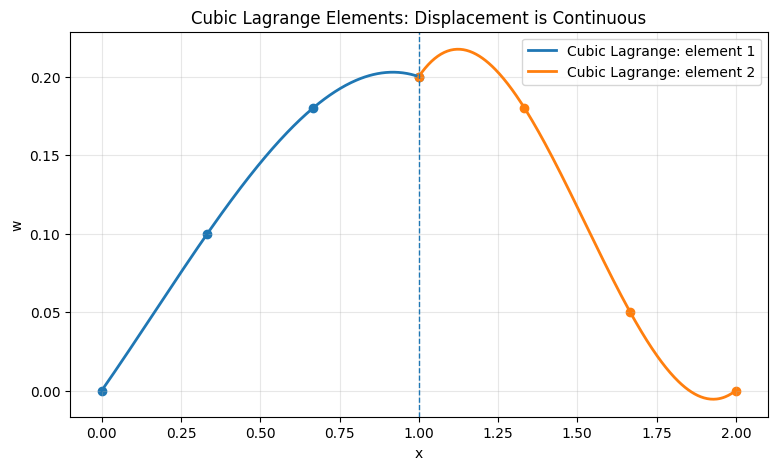

In [7]:
def lagrange_interpolation(x_nodes, w_nodes, x_eval):
    w = np.zeros_like(x_eval, dtype=float)

    for i in range(len(x_nodes)):
        Li = np.ones_like(x_eval, dtype=float)

        for j in range(len(x_nodes)):
            if i != j:
                Li *= (x_eval - x_nodes[j])/(x_nodes[i] - x_nodes[j])

        w += w_nodes[i]*Li

    return w


# Element 1
x1_nodes = np.array([0.0, 1/3, 2/3, 1.0])
w1_nodes = np.array([0.0, 0.10, 0.18, 0.20])

# Element 2
x2_nodes = np.array([1.0, 4/3, 5/3, 2.0])
w2_nodes = np.array([0.20, 0.18, 0.05, 0.00])

x1 = np.linspace(0.0, 1.0, 300)
x2 = np.linspace(1.0, 2.0, 300)

w1 = lagrange_interpolation(x1_nodes, w1_nodes, x1)
w2 = lagrange_interpolation(x2_nodes, w2_nodes, x2)

plt.figure(figsize=(9,5))
plt.plot(x1, w1, linewidth=2, label='Cubic Lagrange: element 1')
plt.plot(x2, w2, linewidth=2, label='Cubic Lagrange: element 2')
plt.scatter(x1_nodes, w1_nodes)
plt.scatter(x2_nodes, w2_nodes)
plt.axvline(1.0, linestyle='--', linewidth=1)
plt.xlabel('x')
plt.ylabel('w')
plt.title('Cubic Lagrange Elements: Displacement is Continuous')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


The displacement curves join at $x=1$. Thus,

$$
w^{(1)}(1)=w^{(2)}(1).
$$

Now calculate the slope on each side of the common node.


In [3]:
# Recover the cubic polynomials and differentiate them
coef1 = np.polyfit(x1_nodes, w1_nodes, 3)
coef2 = np.polyfit(x2_nodes, w2_nodes, 3)

dcoef1 = np.polyder(coef1)
dcoef2 = np.polyder(coef2)

slope_left = np.polyval(dcoef1, 1.0)
slope_right = np.polyval(dcoef2, 1.0)

print(f"w from element 1 at x=1 = {np.polyval(coef1,1.0):.6f}")
print(f"w from element 2 at x=1 = {np.polyval(coef2,1.0):.6f}")
print()
print(f"dw/dx from element 1 at x=1 = {slope_left:.6f}")
print(f"dw/dx from element 2 at x=1 = {slope_right:.6f}")
print()
print(f"Slope jump = {slope_right - slope_left:.6f}")


w from element 1 at x=1 = 0.200000
w from element 2 at x=1 = 0.200000

dw/dx from element 1 at x=1 = -0.070000
dw/dx from element 2 at x=1 = 0.295000

Slope jump = 0.365000


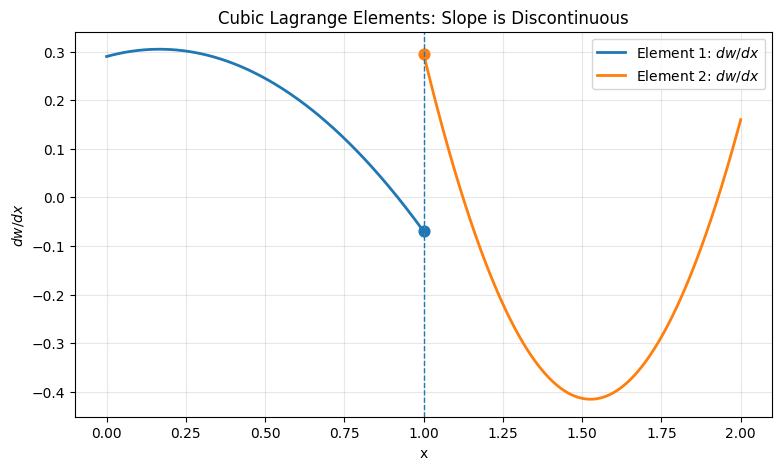

In [4]:
dw1 = np.polyval(dcoef1, x1)
dw2 = np.polyval(dcoef2, x2)

plt.figure(figsize=(9,5))
plt.plot(x1, dw1, linewidth=2, label=r'Element 1: $dw/dx$')
plt.plot(x2, dw2, linewidth=2, label=r'Element 2: $dw/dx$')
plt.scatter([1.0], [slope_left], s=60)
plt.scatter([1.0], [slope_right], s=60)
plt.axvline(1.0, linestyle='--', linewidth=1)
plt.xlabel('x')
plt.ylabel(r'$dw/dx$')
plt.title('Cubic Lagrange Elements: Slope is Discontinuous')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## What is the problem?

For the cubic Lagrange elements,

$$
w^{(1)}(1)=w^{(2)}(1),
$$

but in general,

$$
\left.\frac{dw^{(1)}}{dx}\right|_{x=1}
\neq
\left.\frac{dw^{(2)}}{dx}\right|_{x=1}.
$$

Therefore,

$$
\boxed{\text{Cubic Lagrange interpolation is } C^0 \text{ continuous}}
$$

across ordinary element boundaries.

The point is not that cubic Lagrange interpolation cannot represent a cubic function. It can.

The problem is that its nodal degrees of freedom do not enforce continuity of the first derivative between neighboring elements.


## Comparison with Hermite interpolation

Hermite interpolation introduces both displacement and slope as nodal quantities.

Therefore, neighboring elements can share

$$
w
$$

and

$$
\frac{dw}{dx}
$$

at the common node.

This gives the $C^1$ continuity required by the classical Euler--Bernoulli beam formulation.


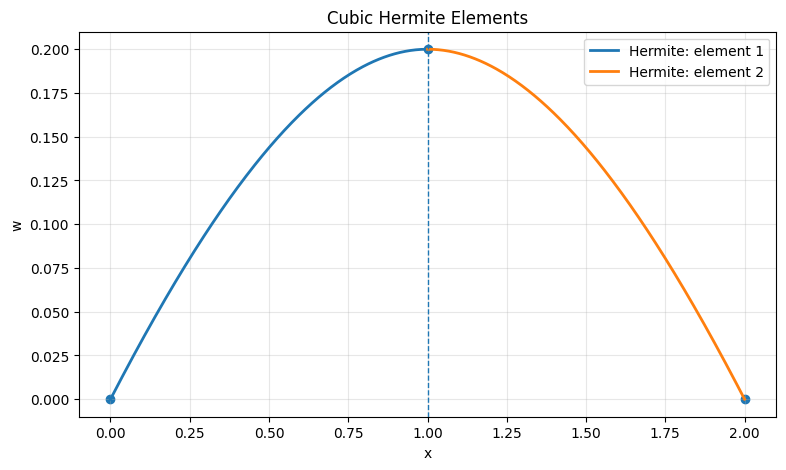

In [5]:
def hermite_element(xa, xb, wa, slope_a, wb, slope_b, n=300):
    h = xb - xa
    x = np.linspace(xa, xb, n)
    xi = (x - xa)/h

    H1 = 1 - 3*xi**2 + 2*xi**3
    H2 = h*(xi - 2*xi**2 + xi**3)
    H3 = 3*xi**2 - 2*xi**3
    H4 = h*(-xi**2 + xi**3)

    w = H1*wa + H2*slope_a + H3*wb + H4*slope_b
    return x, w


# Two Hermite elements sharing the same displacement and slope at x = 1
xh1, wh1 = hermite_element(0.0, 1.0, 0.0, 0.35, 0.20, 0.0)
xh2, wh2 = hermite_element(1.0, 2.0, 0.20, 0.0, 0.0, -0.35)

plt.figure(figsize=(9,5))
plt.plot(xh1, wh1, linewidth=2, label='Hermite: element 1')
plt.plot(xh2, wh2, linewidth=2, label='Hermite: element 2')
plt.scatter([0,1,2], [0,0.20,0])
plt.axvline(1.0, linestyle='--', linewidth=1)
plt.xlabel('x')
plt.ylabel('w')
plt.title('Cubic Hermite Elements')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


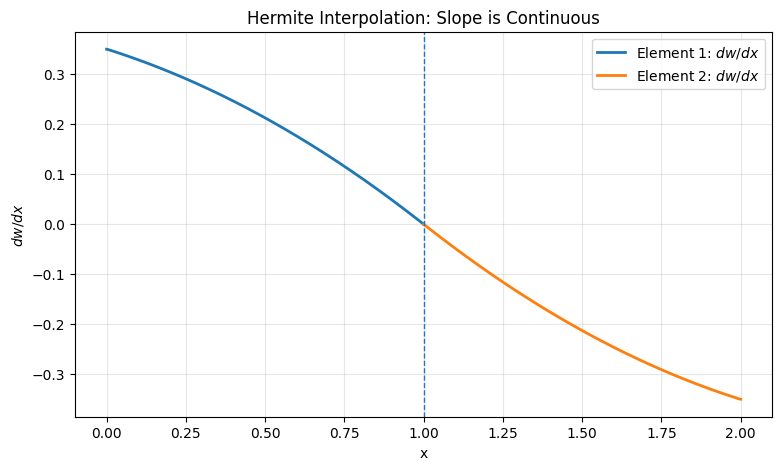

In [6]:
dwh1 = np.gradient(wh1, xh1)
dwh2 = np.gradient(wh2, xh2)

plt.figure(figsize=(9,5))
plt.plot(xh1, dwh1, linewidth=2, label=r'Element 1: $dw/dx$')
plt.plot(xh2, dwh2, linewidth=2, label=r'Element 2: $dw/dx$')
plt.axvline(1.0, linestyle='--', linewidth=1)
plt.xlabel('x')
plt.ylabel(r'$dw/dx$')
plt.title('Hermite Interpolation: Slope is Continuous')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Cubic Lagrange vs. cubic Hermite

| Property | Cubic Lagrange | Cubic Hermite |
|---|---|---|
| Polynomial order | Cubic | Cubic |
| \(w\) continuous between elements | Yes | Yes |
| \(dw/dx\) automatically continuous | No | Yes |
| Inter-element continuity | \(C^0\) | \(C^1\) |
| Classical Euler--Bernoulli beam formulation | Not directly suitable | Suitable |

The important conclusion is

$$
\boxed{\text{Polynomial order alone is not sufficient.}}
$$
A cubic Lagrange polynomial is still only $C^0$-continuous across ordinary finite-element boundaries.

The Hermite interpolation is used because it provides the required

$$
\boxed{C^1\text{ continuity}.}
$$
